In [6]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
ipo_name = data["IPO_Name"]      
X = data.drop(["List Price", "IPO_Name", "Date"] ,axis = 1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)

model = RandomForestRegressor()
model.fit(X_train ,y_train)
rf_pred = model.predict(X_test)

print(rf_pred[:10])



[ 14.698   61.514   63.4761 105.0819 677.56   139.816  258.156  550.757
 779.7825 218.944 ]


In [9]:
comperison = pd.DataFrame({
    "Actual price" : y_test,
    "predicted price" : rf_pred
})
print(comperison)

     Actual price  predicted price
465         10.10          14.6980
441         55.80          61.5140
593         52.13          63.4761
458        110.00         105.0819
41         660.00         677.5600
..            ...              ...
195        360.50         366.5535
135        137.75         133.4015
411        313.00         324.8890
159        163.30         141.3055
250        141.00         130.1479

[131 rows x 2 columns]


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 25.204749618320616
RMSE: 73.44966542122727
R2  : 0.9699917761887291


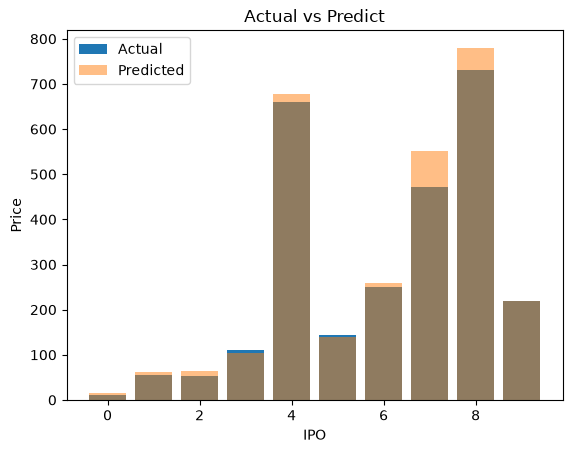

In [11]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), rf_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()

In [12]:
import joblib
joblib.dump(model , "random_forest.pkl")

['random_forest.pkl']